# 📊 Supermarket Sales Data Analysis (EDA Project)

## 🧾 Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail dataset to uncover meaningful insights about sales patterns, customer segments, product categories, and regional performance.

## 📁 Dataset Description
The dataset contains information about:
- Orders and shipping details
- Customer information
- Product categories
- Sales data

## 🛠 Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv("supermarket.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [49]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Day                       int32
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 🔍 Missing Values Analysis

We check for missing values to understand data quality. Depending on the importance of the column, we will decide whether to drop or impute missing values.

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
# percentage of missing values
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

In [10]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mode()[0])

In [12]:
# convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [52]:
df['Year'] = df['Order Date'].dt.year.astype(int)

In [53]:
df['Month'] = df['Order Date'].dt.month.astype(int)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Feature Engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

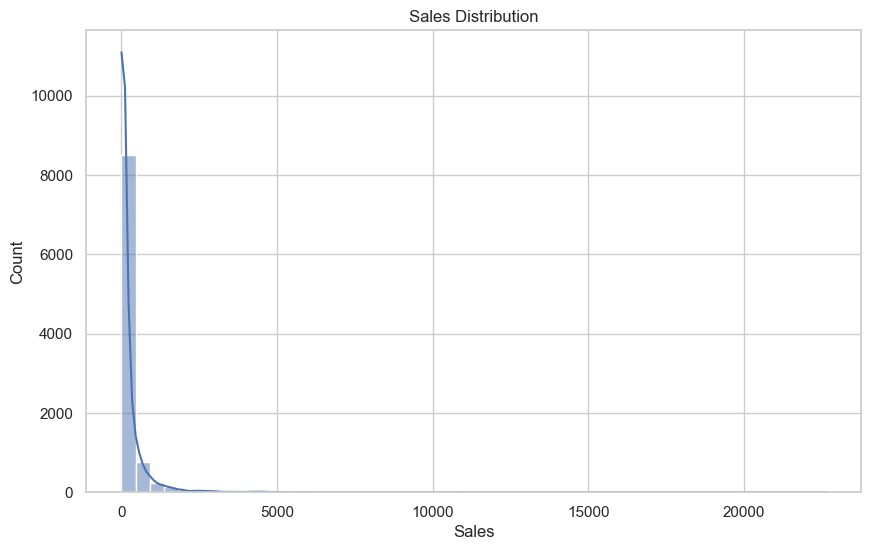

In [15]:
# Sales Distribution
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

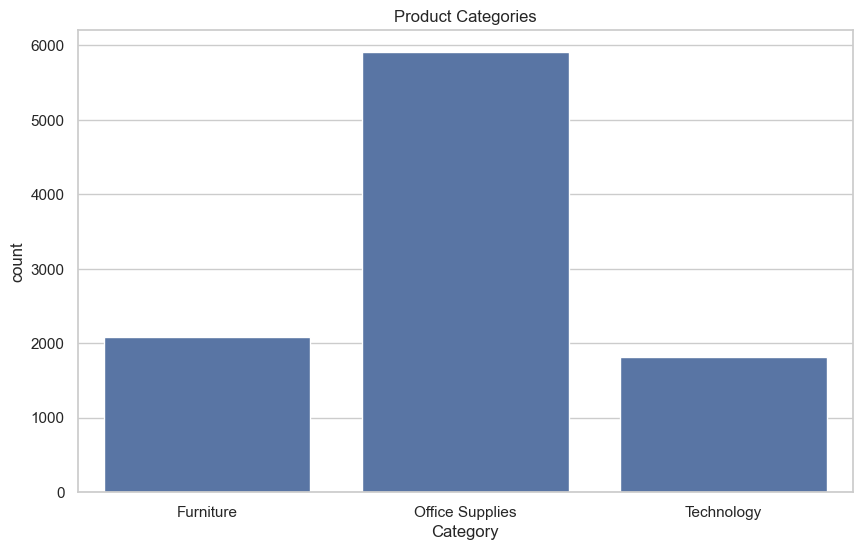

In [16]:
# Category Count
sns.countplot(x='Category', data=df)
plt.title("Product Categories")
plt.show()

In [23]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
category_sales

,sum,mean,count
Category,,,
Technology,827455.8730,456.401474,1813
Furniture,728658.5757,350.653790,2078
Office Supplies,705422.3340,119.381001,5909


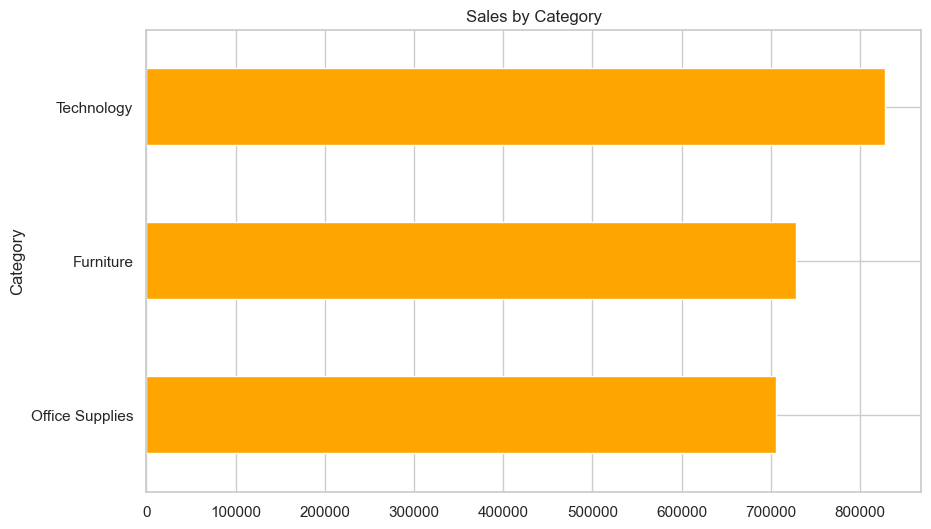

In [64]:
category_sales.plot(kind='barh', color='orange')
plt.title("Sales by Category")
plt.show()

In [32]:
# Sales By Sub-Category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
subcat_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

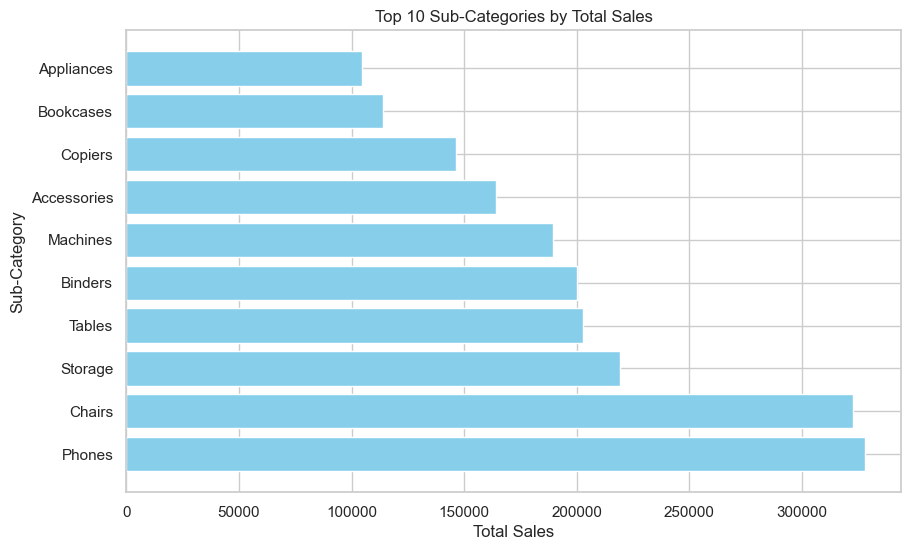

In [31]:
plt.figure(figsize=(10,6))
plt.barh(subcat_sales.index, subcat_sales.values, color='skyblue')
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.title("Top 10 Sub-Categories by Total Sales")
plt.show()

In [33]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
region_sales

,sum,mean,count
Region,,,
West,710219.6845,226.184613,3140
East,669518.7260,240.401697,2785
Central,492646.9132,216.357889,2277
South,389151.4590,243.524067,1598


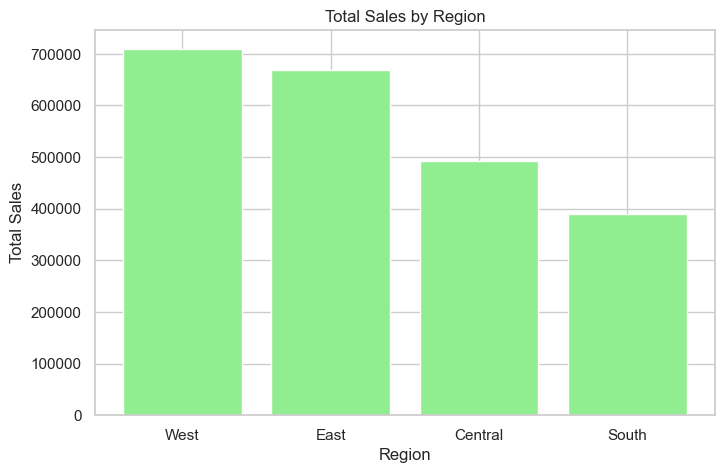

In [35]:
region_sales_sorted = region_sales.sort_values(by='sum', ascending=False)

plt.figure(figsize=(8,5))
plt.bar(region_sales_sorted.index, region_sales_sorted['sum'], color='lightgreen')
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region")
plt.show()

In [36]:
# Segment Analysis
segment_sales = df.groupby('Segment')['Sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
segment_sales

,sum,mean,count
Segment,,,
Consumer,1.148061e+06,225.065777,5101
Corporate,6.884941e+05,233.150720,2953
Home Office,4.249822e+05,243.403309,1746


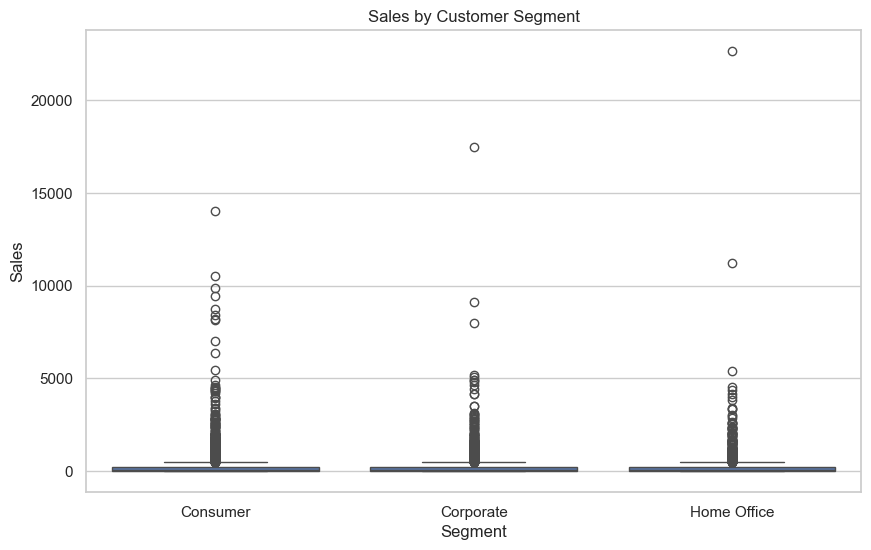

In [37]:
sns.boxplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Customer Segment")
plt.show()

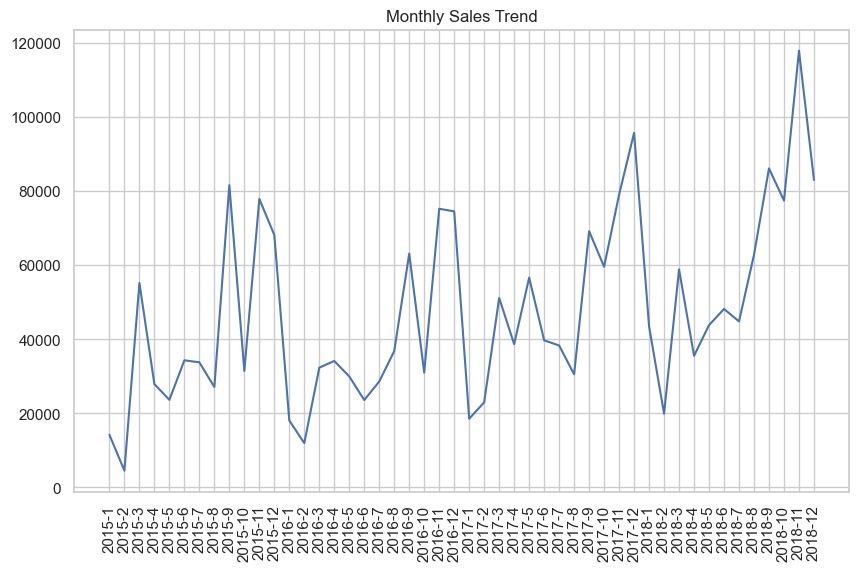

In [20]:
# Time Series Analysis
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_sales['Year-Month'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)

plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'])
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.show()

In [47]:
year_sales = df.groupby('Year')['Sales'].sum()
year_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

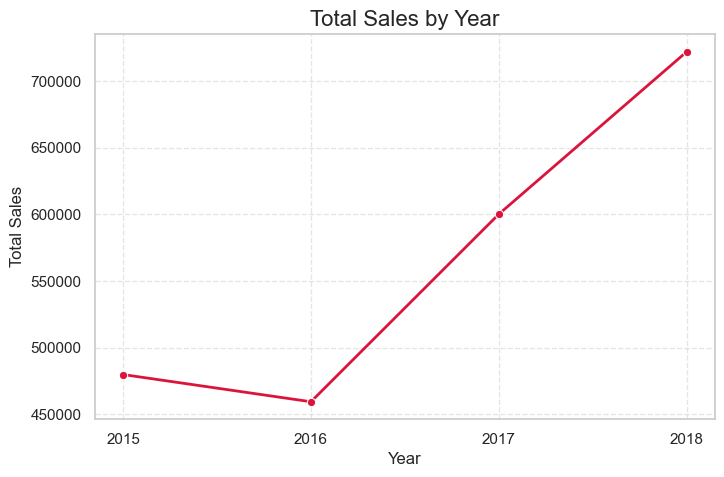

In [59]:
year_sales = df.groupby('Year')['Sales'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(data=year_sales, x='Year', y='Sales', marker='o', linewidth=2, color='crimson')
plt.title('Total Sales by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(year_sales['Year']) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [60]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

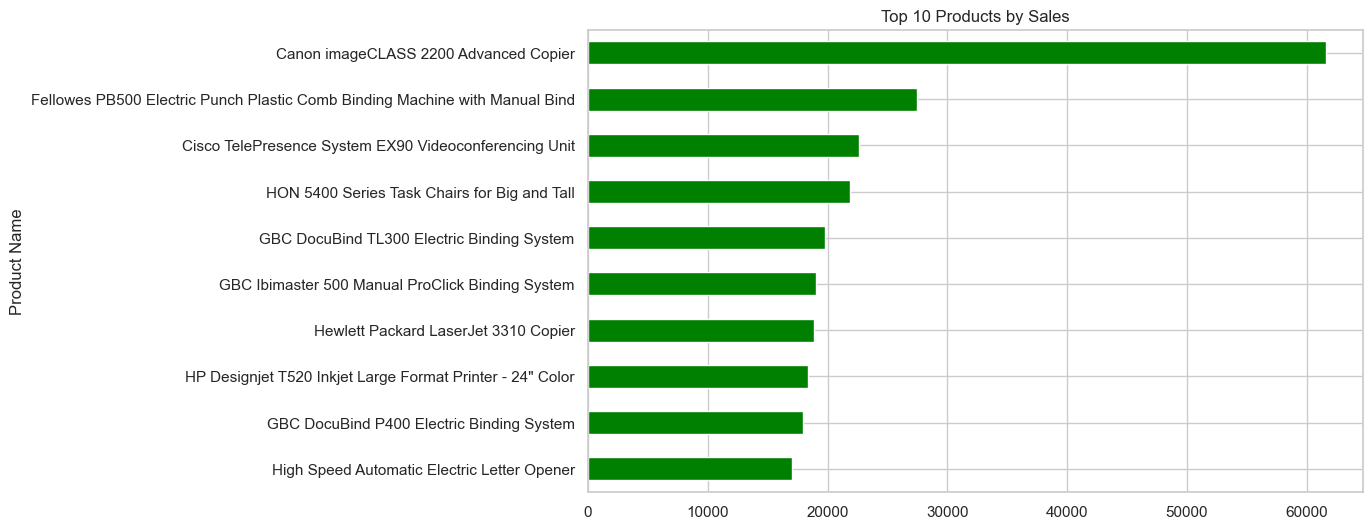

In [61]:
# Top Products
top_products.plot(kind='barh', color='green')
plt.title("Top 10 Products by Sales")
plt.gca().invert_yaxis()
plt.show()

In [46]:
# Top Customers
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

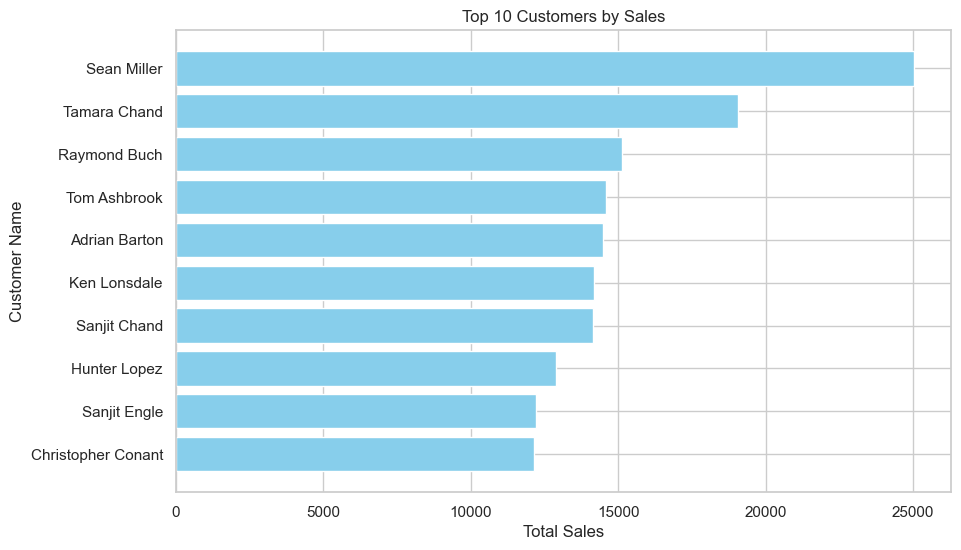

In [39]:
plt.figure(figsize=(10,6))
plt.barh(top_customers.index, top_customers.values, color='skyblue')
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Sales")
plt.gca().invert_yaxis()  # Highest sales on top
plt.show()

In [62]:
# State Wise Sales
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
state_sales

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

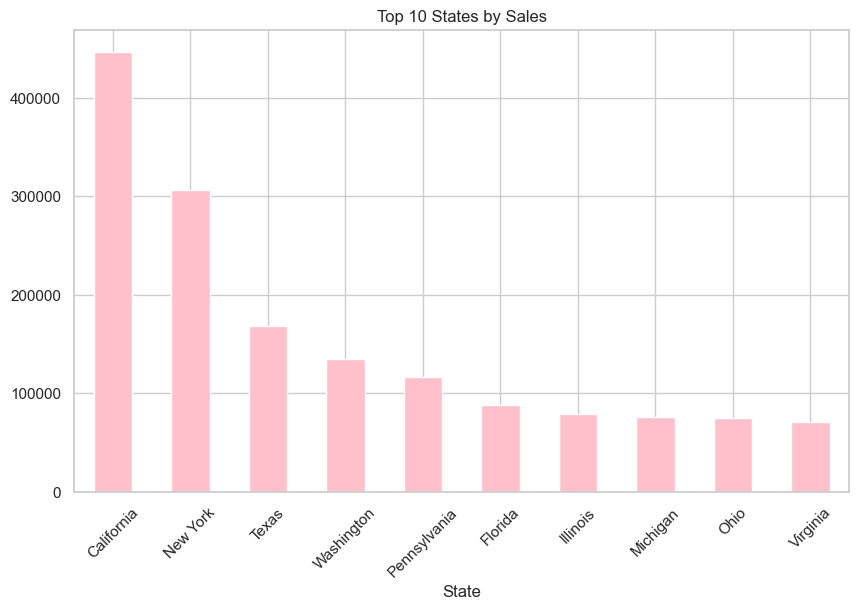

In [63]:
state_sales.plot(kind='bar', color='pink')
plt.title("Top 10 States by Sales")
plt.xticks(rotation=45)
plt.show()

## 💡 Key Business Insights

### Overall Sales Performance
- The total sales generated are 2.26 million, indicating strong overall business performance.
- The average order value is 230.77, suggesting moderate transaction size.
- Sales range from 0.44 to 22,638, showing a high variation between low-value and high-value transactions.

---

### Category-Level Insights
- Technology is the top-performing category with 827K in sales.
- It also has the highest average sales per order (456), indicating high-value products.
- Office Supplies has the highest number of orders (5909) but a lower average sales value.
- Furniture shows moderate performance in both sales and order volume.

Business Insight:
Technology drives revenue, while Office Supplies drives volume.

---

### Sub-Category Insights
- Top sub-categories by sales:
  - Phones (~327K)
  - Chairs (~322K)
  - Storage (~219K)
- Machines and Copiers contribute significantly despite fewer orders.

Business Insight:
A few sub-categories contribute a large portion of total revenue.

---

### Regional Performance
- West region generates the highest sales (~710K).
- East region has the highest average order value (~240).
- South region also shows high average sales despite lower total sales.

Business Insight:
West leads in total sales, while East and South have higher-value transactions.

---

### Customer Segment Analysis
- Consumer segment contributes the highest revenue (~1.14M).
- Home Office segment has the highest average sales (~243).

Business Insight:
Consumer segment drives volume, while Home Office customers spend more per order.

---

### Top Customers
- A small number of customers contribute significantly to revenue.
- Top customer (Sean Miller) generated over 25K in sales.

Business Insight:
Customer spending is concentrated among a few high-value customers.

---

### State-Level Insights
- California (~446K) and New York (~306K) are the top-performing states.
- Texas ranks third but significantly behind.

Business Insight:
Sales are concentrated in a few key states, indicating geographic dependency.

---

### Yearly Growth Trend
- Sales increased consistently from 2015 to 2018:
  - 2015: 479K
  - 2016: 459K
  - 2017: 600K
  - 2018: 722K

Business Insight:
The business shows strong and consistent growth over time.

---

### Monthly Trends (Seasonality)
- Highest sales occur in November (~350K) and December (~321K).
- Lowest sales occur in January and February.

Business Insight:
Sales peak during the holiday season (Q4).

---

### Product-Level Insights
- Top product: Canon imageCLASS 2200 Advanced Copier (~61K).
- Many top products are office machines and equipment.

Business Insight:
High-value office equipment contributes significantly to overall revenue.

---

## ✅ Final Conclusion
- Technology drives high revenue, while Office Supplies contributes to high sales volume.
- Sales are concentrated in specific regions and states.
- A small number of customers and products contribute heavily to total revenue.
- There is a strong seasonal trend with peak sales in Q4.
- The business shows consistent year-over-year growth.